In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import block_diag
from scipy.signal import savgol_filter
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler as minmax_scaler
from sklearn.preprocessing import StandardScaler as std_scaler

import utilities as utils

In [2]:
# ---------------------------------------------------------------------------*/
# - parameters of a cavity radio frequency model

q_rf     = 4e7 # loaded quality factor

f_rf     = 1.3e9
w_rf     = 2 * np.pi * f_rf
w_hbw_rf = w_rf/2/q_rf
f_hbw_rf = w_hbw_rf/2/np.pi
t_rf     = round(1/f_hbw_rf, 2)

# generator voltage
v_rf = [10., 0.]

pctr_on_rf = True
K_rf = 100. # proportional controller gain

a_rf = np.array([
    [-w_hbw_rf,  0.      ],
    [ 0.,       -w_hbw_rf]])

b_rf = np.array([
    [w_hbw_rf, 0       ],
    [0,        w_hbw_rf]])

print(f'inf >> half-bandwidth of this radio frequency cavity is {f_hbw_rf:.2f} Herz')
print(f'inf >> cavity filling time is {t_rf:.2f} seconds')

inf >> half-bandwidth of this radio frequency cavity is 16.25 Herz
inf >> cavity filling time is 0.06 seconds


In [3]:
# ---------------------------------------------------------------------------*/
# - parameters of a cavity mechanical model

def make_a_m(w, q):
    return np.array([
        [ 0,             1  ],
        [-np.square(w), -w/q]])

def make_b_m(k, w): 
    return np.array([
        [0              ],
        [-k*np.square(w)]])

f_m = np.array([10.])
w_m = 2 * np.pi * f_m
q_m = np.ones_like(f_m) * 10.
k_m = np.ones_like(f_m) * 2 * np.pi * 1. # coupling with units (2 * pi * Hz) / (MV/m)^2

modes_m_n = len(f_m)
print(f'inf >> number of mechanical modes specified: {modes_m_n}')

# assemble system and input matrices, A and B
a_m = block_diag(*[make_a_m(w, q) for w, q in zip(w_m, q_m)])
b_m = np.concatenate([make_b_m(k, w) for k, w in zip(k_m, w_m)], axis=0)


inf >> number of mechanical modes specified: 1


In [4]:
# ---------------------------------------------------------------------------*/
# - solving differential equations

def cav_fn(t, x):
    """
    Executes the logic of cavity differential equations. Input parameters ``t``
    and ``x`` are time and state, respectively.
    """

    # current state of a cavity field: real and imaginary components
    x_rf = np.array(x[:2]).reshape((-1, 1))

    # current states of all mechanical modes: displacements and velocities
    x_m = np.array(x[2:]).reshape((-1, 1))

    # input to cavity field: real and imaginary parts of a generator voltage
    u_rf = np.zeros((2, 1))
    if pctr_on_rf:
        # proportional control is on, so calculate an actuation signal u
        r_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

        e_rf = r_rf - x_rf

        u_rf = K_rf * e_rf
    else:
        # proportional control is off, so our setpoint becomes our actuation signal
        u_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

    # input to mechanical mode: accelerating field gradient squared
    grad = np.sqrt(np.square(x_rf[0]) + np.square(x_rf[1])) # todo: add division by cavity length
    u_m = np.square(grad)

    # update detuning in cavity system dynamics
    disp_m = np.sum([x_m[2*i] for i in range(modes_m_n)])
    a_rf[0, 1] = -disp_m
    a_rf[1, 0] =  disp_m

    # calculate derivatives
    dx_rf = a_rf @ x_rf + b_rf @ u_rf
    dx_m  = a_m  @ x_m  + b_m  * u_m

    return np.array([
        *dx_rf.flatten(),
        *dx_m.flatten()])

t_span = [0, 4*t_rf]
dt = 0.001
t = np.arange(t_span[0], t_span[1], dt)

# every mechanical mode has two states:
# 1. displacement
# 2. velocity
modes_m = np.zeros(modes_m_n * 2)

x0 = [
    0,         # cavity field real
    0,         # cavity field imaginary
    *modes_m ] # all mechanical modes 

y = solve_ivp(cav_fn, t_span, x0, method='RK45', t_eval=t)

inf >> time step for simulation is 0.0010
inf >> number of time steps is 240
inf >> starting index to skip a transient process is 10
inf >> the shape of scaled mechanical states is (230, 2)
inf >> the shape of scaled rf input is (230, 1)


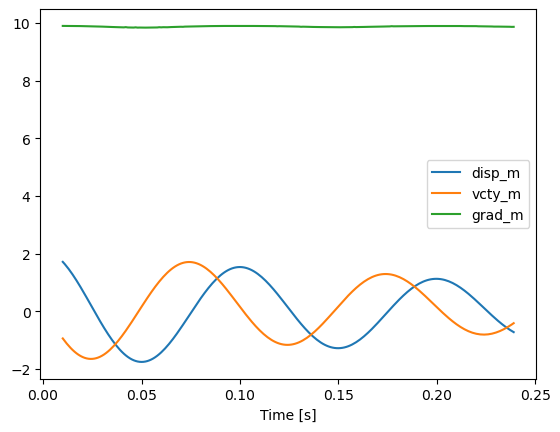

In [5]:
# ---------------------------------------------------------------------------*/
# - conditioning simulated data

print(f'inf >> time step for simulation is {dt:.4f}')
print(f'inf >> number of time steps is {len(t)}')

# sum detuning
disp_m = np.zeros_like(y.y[2])
for i in range(modes_m_n):
    disp_m = disp_m + y.y[2 + 2*i]

# sum velocity
vcty_m = np.zeros_like(y.y[3])
for i in range(modes_m_n):
    vcty_m = vcty_m + y.y[3 + 2*i]

# compute cavity field gradient
fld_r_rf = y.y[0, :]
fld_i_rf = y.y[1, :]
grad_m = np.sqrt(np.square(fld_r_rf) + np.square(fld_i_rf))

# we want to skip the transient process of an RF cavity when scaling data
start_i = 10
print(f'inf >> starting index to skip a transient process is {start_i}')

# scale mechanical state data starting from the transient-skipping index
#
# also, mechanical states are sinusoids that toggle around 0, so we can apply
# standard scaling, thus removing a mean and making the variance equal one
states_m = np.vstack([
    disp_m[start_i:],
    vcty_m[start_i:]]).T
states_scaler = std_scaler()
states_m_sca = states_scaler.fit_transform(states_m)
print(f'inf >> the shape of scaled mechanical states is {states_m_sca.shape}')

# RF field is treated in terms of its envelope stabilized by a controller, so
# it is supposed to be a more or less stable horizontal line
input_m = np.vstack([
    grad_m[start_i:]]).T
input_scaler = std_scaler(with_mean=False, with_std=False)
input_m_sca = input_scaler.fit_transform(input_m)
print(f'inf >> the shape of scaled rf input is {input_m_sca.shape}')

plt.figure()
plt.plot(y.t[start_i:], states_m_sca[:, 0], label='disp_m')
plt.plot(y.t[start_i:], states_m_sca[:, 1], label='vcty_m')
plt.plot(y.t[start_i:], input_m_sca[:, 0], label='grad_m')
plt.legend()
plt.xlabel('Time [s]')
plt.show()

inf >> the shape of scaled derivatives of mechanical states is (229, 2)


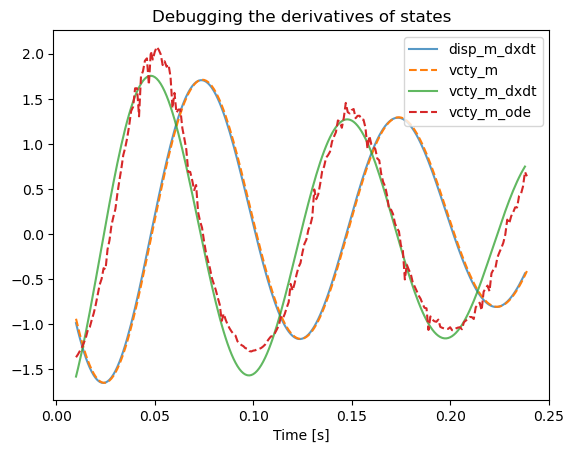

In [6]:
# ---------------------------------------------------------------------------*/
# - debugging the derivatives of states

dx1dt_m = np.diff(states_m_sca[:, 0]) / dt
dx2dt_m = np.diff(states_m_sca[:, 1]) / dt

dxdt_m = np.vstack([dx1dt_m, dx2dt_m]).T
dxdt_m_sca = states_scaler.fit_transform(dxdt_m)
print(f'inf >> the shape of scaled derivatives of mechanical states is {dxdt_m_sca.shape}')

# calculate mechanical derivatives according to differential equations
#
# everything is supposed to be scaled
dx1dt_m_ode = states_m_sca[:, 1]
dx2dt_m_ode = -np.square(w_m) * states_m_sca[:, 0] - (w_m/q_m) * states_m_sca[:, 1] - k_m * np.square(w_m) * np.square(input_m_sca[:, 0])

dxdt_m_ode = np.vstack([dx1dt_m_ode, dx2dt_m_ode]).T
dxdt_m_ode_sca = states_scaler.fit_transform(dxdt_m_ode)

plt.figure()
plt.title('Debugging the derivatives of states')
plt.plot(y.t[start_i:-1], dxdt_m_sca[:, 0], color='tab:blue', alpha=0.75, label='disp_m_dxdt')
plt.plot(y.t[start_i:], states_m_sca[:, 1], label='vcty_m', color='tab:orange', linestyle='dashed')
plt.plot(y.t[start_i:-1], dxdt_m_sca[:, 1], color='tab:green', alpha=0.75, label='vcty_m_dxdt')
plt.plot(y.t[start_i:], dxdt_m_ode_sca[:, 1], label='vcty_m_ode', color='tab:red', linestyle='dashed')
plt.legend()
plt.xlabel('Time [s]')
plt.show()

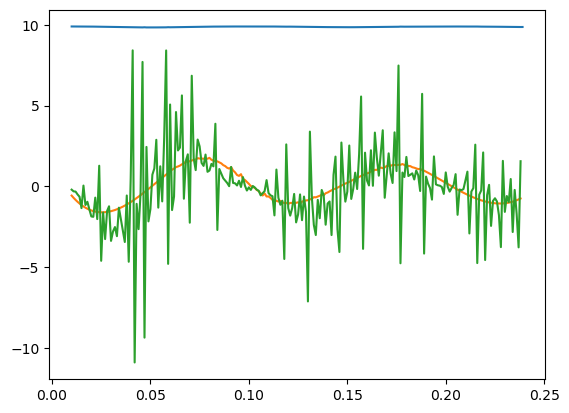

inf >> the shape of scaled derivatives of RF field input is (229, 1)


In [7]:
# ---------------------------------------------------------------------------*/
# - derivative of input u

# compute a derivative from the portion of u that skips its transient process
du_m = np.diff(grad_m[start_i:]) / dt

# save the non-smooth version of the derivative
du_m_nonsmooth = du_m

# smooth the derivative
du_m = savgol_filter(du_m, window_length=100, polyorder=3)

# make the derivative data a column
du_m = du_m[:, np.newaxis]

# the derivative can be negative
du_scaler = std_scaler()
du_m_sca = du_scaler.fit_transform(du_m)

plt.figure()
plt.plot(y.t[start_i:], input_m_sca[:, 0])
plt.plot(y.t[start_i:-1], du_m_sca[:, 0])
plt.plot(y.t[start_i:-1], du_m_nonsmooth)
plt.show()

print(f'inf >> the shape of scaled derivatives of RF field input is {du_m_sca.shape}')


In [8]:
# ---------------------------------------------------------------------------*/
# - saving simulation data to files

savedata_on = True

# create a default random number generator
rng = np.random.default_rng()

def from_timeseries(savedata_len, ts_len, *ts):

    savedata_start = int((ts_len - savedata_len) * rng.random())
    savedata_end   = savedata_start + savedata_len

    return np.concatenate([
        ts_this[savedata_start:savedata_end, np.newaxis] for ts_this in ts], axis=1)

dataset_dir = 'cavity/10Hz'

savedata_config = [
    # batch size, file name
    (3500, 'train1'),
    (3500, 'train2'),
    (3500, 'train3'),
    (3500, 'train4'),
    (3500, 'train5'),
    (3500, 'train6'),
    (1000, 'valid'),
    (500,  'test')]

savedata_len = 151
timeseries_len = len(dxdt_m_sca[:, 0])

if savedata_on:

    for this, cfg in enumerate(savedata_config):
        np.random.seed(this + 1)
        data = np.stack([
            from_timeseries(
                savedata_len,
                timeseries_len,
                states_m_sca[:timeseries_len, 0],
                states_m_sca[:timeseries_len, 1],
                dxdt_m_sca[:timeseries_len, 0],
                dxdt_m_sca[:timeseries_len, 1],
                input_m_sca[:timeseries_len, 0],
                du_m_sca[:timeseries_len, 0]) for _ in range(cfg[0])], axis=0)

        utils.write_datafile(f'{dataset_dir}/{cfg[1]}', data)
    print('inf >> files saved')
else:
    print('wrn >> file saving is switched off')


inf >> files saved
